# Battery-Constrained Rover Planning: Final Experiment

## Research question

**How do onboard memory, mission size, and time-dependent data degradation affect the feasibility, efficiency, and planning difficulty of a battery-constrained rover mission?**

The rover must travel across terrain, collect and encode scientific datasets, keep them in limited onboard memory, return to base, and offload the data before corruption makes them unusable. Movement also consumes a fixed battery budget.

I used seeds 0–4 while developing and checking the model. After freezing the configuration, I ran the final experiment on unseen seeds 10–14.

### Final experimental design

- Dataset count: 2, 3, or 4
- Memory level: low, medium, or high
- Corruption level: low, medium, or high
- Final seeds: 10–14
- Battery capacity: 40 energy units
- Planner: ENHSP with `sat-hadd`
- Standard timeout: 30 seconds
- Extended timeout for the three unresolved cases: 120 seconds
- Total final instances: 135

The 30-second runs are used for runtime analysis. The final solved or unsolvable labels are used for feasibility analysis.

### Figures used in the study

The notebook uses five main figures, each answering a different question:

1. How does each experimental factor affect mission success?
2. How do mission size and memory interact?
3. How does mission size affect planner runtime?
4. How much battery remains after solved missions?
5. How are movement energy and plan makespan related?


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import chi2_contingency, friedmanchisquare, kruskal

warnings.filterwarnings("ignore", category=FutureWarning)

DATASET_ORDER = [2, 3, 4]
MEMORY_ORDER = ["low", "medium", "high"]
CORRUPTION_ORDER = ["low", "medium", "high"]
STANDARD_STATUS_ORDER = ["solved", "unsolvable", "timeout"]
CLASSIFICATION_STATUS_ORDER = ["solved", "unsolvable"]


def find_project_root(start: Path) -> Path:
    resolved = start.resolve()

    for candidate in [resolved, *resolved.parents]:
        result_file = (
            candidate
            / "experiments"
            / "results"
            / "battery_final_unseen.csv"
        )
        if result_file.exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository. Start JupyterLab from the "
        "project folder or one of its subdirectories."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

STANDARD_RESULTS_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "battery_final_unseen.csv"
)

CLASSIFIED_RESULTS_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "battery_final_unseen_classified.csv"
)

PLOT_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "plots"
    / "battery_final"
)

TABLE_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "tables"
    / "battery_final"
)

PLOT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project paths configured.")


Project paths configured.


## 1. Load and validate the final experiment

Two result files are used:

- `battery_final_unseen.csv` contains the original 30-second planner runs;
- `battery_final_unseen_classified.csv` contains the final classification after rerunning only the three timeout cases.

The checks below confirm that the final dataset has the expected size, seeds, model, battery capacity, and valid solved plans.


In [2]:
standard_df = pd.read_csv(STANDARD_RESULTS_PATH)
classified_df = pd.read_csv(CLASSIFIED_RESULTS_PATH)

numeric_columns = [
    "seed",
    "dataset_count",
    "memory_ratio",
    "memory_capacity",
    "total_dataset_size",
    "memory_utilization_ratio",
    "average_travel_time_per_edge",
    "total_one_way_travel_time",
    "optimistic_minimum_energy",
    "battery_capacity",
    "battery_headroom",
    "safe_dataset_count",
    "unsafe_dataset_count",
    "timeout_seconds",
    "wall_runtime_seconds",
    "reported_plan_length",
    "reported_elapsed_time",
    "plan_makespan",
    "travel_time_in_plan",
    "estimated_travel_time",
    "stationary_time",
    "energy_used",
    "battery_remaining",
    "battery_utilization_ratio",
    "action_count",
    "move_actions",
    "collect_actions",
    "offload_actions",
    "waiting_periods",
    "total_waiting_time",
    "standard_runtime_seconds",
    "classification_runtime_seconds",
]

for frame in [standard_df, classified_df]:
    for column in numeric_columns:
        if column in frame.columns:
            frame[column] = pd.to_numeric(
                frame[column],
                errors="coerce",
            )

for frame in [standard_df, classified_df]:
    frame["dataset_count"] = frame["dataset_count"].astype(int)
    frame["seed"] = frame["seed"].astype(int)
    frame["memory_level"] = pd.Categorical(
        frame["memory_level"],
        categories=MEMORY_ORDER,
        ordered=True,
    )
    frame["corruption_level"] = pd.Categorical(
        frame["corruption_level"],
        categories=CORRUPTION_ORDER,
        ordered=True,
    )

classified_df["standard_status"] = pd.Categorical(
    classified_df["standard_status"],
    categories=STANDARD_STATUS_ORDER,
    ordered=True,
)

classified_df["classification_status"] = pd.Categorical(
    classified_df["classification_status"],
    categories=CLASSIFICATION_STATUS_ORDER,
    ordered=True,
)

display(
    classified_df[
        [
            "instance_id",
            "dataset_count",
            "memory_level",
            "corruption_level",
            "seed",
            "standard_status",
            "classification_status",
            "classification_source",
        ]
    ].head()
)


,instance_id,dataset_count,memory_level,corruption_level,seed,standard_status,classification_status,classification_source
0,rover-battery-n2-mem-low-corr-low-seed-10,2,low,low,10,solved,solved,standard_30s
1,rover-battery-n2-mem-low-corr-low-seed-11,2,low,low,11,solved,solved,standard_30s
2,rover-battery-n2-mem-low-corr-low-seed-12,2,low,low,12,solved,solved,standard_30s
3,rover-battery-n2-mem-low-corr-low-seed-13,2,low,low,13,solved,solved,standard_30s
4,rover-battery-n2-mem-low-corr-low-seed-14,2,low,low,14,solved,solved,standard_30s


In [3]:
assert len(standard_df) == 135, (
    f"Expected 135 standard rows, found {len(standard_df)}."
)
assert len(classified_df) == 135, (
    f"Expected 135 classified rows, found {len(classified_df)}."
)

assert standard_df["instance_id"].is_unique
assert classified_df["instance_id"].is_unique
assert set(standard_df["instance_id"]) == set(classified_df["instance_id"])

assert set(classified_df["dataset_count"]) == set(DATASET_ORDER)
assert set(classified_df["seed"]) == {10, 11, 12, 13, 14}
assert classified_df["model"].eq("battery").all()
assert classified_df["battery_capacity"].eq(40).all()
assert classified_df["unsafe_dataset_count"].fillna(0).eq(0).all()

standard_counts = (
    classified_df["standard_status"]
    .value_counts()
    .reindex(STANDARD_STATUS_ORDER, fill_value=0)
)

classification_counts = (
    classified_df["classification_status"]
    .value_counts()
    .reindex(CLASSIFICATION_STATUS_ORDER, fill_value=0)
)

assert int(standard_counts["timeout"]) == 3
assert classified_df["classification_status"].notna().all()
assert classified_df["classification_source"].eq(
    "extended_120s"
).sum() == 3

solved_rows = classified_df[
    classified_df["classification_status"].astype(str).eq("solved")
].copy()

battery_valid = (
    solved_rows["battery_feasible"]
    .astype(str)
    .str.lower()
    .eq("true")
)

route_valid = (
    solved_rows["route_metrics_valid"]
    .astype(str)
    .str.lower()
    .eq("true")
)

assert battery_valid.all()
assert route_valid.all()
assert solved_rows["battery_remaining"].ge(-1e-9).all()

print("Final experiment validation passed.")
print("Standard 30-second outcomes:")
display(standard_counts.rename("instances").to_frame())
print("Final feasibility classifications:")
display(classification_counts.rename("instances").to_frame())


Final experiment validation passed.
Standard 30-second outcomes:


,instances
standard_status,
solved,107
unsolvable,25
timeout,3


Final feasibility classifications:


,instances
classification_status,
solved,108
unsolvable,27


## 2. Planner outcomes and timeout classification

A timeout is not treated as proof that a mission is unsolvable. The three missions that reached the 30-second limit were rerun with a 120-second limit. The table shows how the original outcomes changed after this final classification step.


In [4]:
status_table = pd.DataFrame(
    {
        "Standard 30-second outcome": standard_counts,
        "Final classification": (
            classification_counts
            .reindex(STANDARD_STATUS_ORDER, fill_value=0)
        ),
    }
)

display(status_table)

extended_cases = classified_df[
    classified_df["classification_source"].eq("extended_120s")
][
    [
        "instance_id",
        "standard_status",
        "standard_runtime_seconds",
        "classification_status",
        "classification_runtime_seconds",
        "plan_makespan",
    ]
].copy()

print("Cases rerun with the 120-second limit")
display(extended_cases)


,Standard 30-second outcome,Final classification
solved,107,108
unsolvable,25,27
timeout,3,0


Cases rerun with the 120-second limit


,instance_id,standard_status,standard_runtime_seconds,classification_status,classification_runtime_seconds,plan_makespan
92,rover-battery-n4-mem-low-corr-low-seed-12,timeout,30.107204,unsolvable,73.727800,NaN
94,rover-battery-n4-mem-low-corr-low-seed-14,timeout,30.109172,unsolvable,77.297805,NaN
123,rover-battery-n4-mem-high-corr-low-seed-13,timeout,30.119575,solved,35.325328,23.0


The standard experiment produced 107 solved cases, 25 unsolvable cases, and 3 timeouts. After the longer reruns, the final classification contained 108 solved missions and 27 unsolvable missions, with no unresolved cases.


## 3. Mission feasibility

This section studies whether a valid mission plan exists. Feasibility is compared across mission size, memory level, and corruption level. The interaction between dataset count and memory is especially important because memory may have little effect on small missions but become critical as the workload grows.


In [5]:
def summarize_feasibility(
    frame: pd.DataFrame,
    group_columns,
) -> pd.DataFrame:
    """Count classified outcomes and calculate mission success rate."""
    if isinstance(group_columns, str):
        group_columns = [group_columns]

    records = []

    for keys, group in frame.groupby(
        group_columns,
        observed=True,
        sort=False,
    ):
        if not isinstance(keys, tuple):
            keys = (keys,)

        record = dict(zip(group_columns, keys))
        statuses = group["classification_status"].astype(str)

        solved = int(statuses.eq("solved").sum())
        unsolvable = int(statuses.eq("unsolvable").sum())
        total = len(group)

        record.update(
            {
                "instances": total,
                "solved": solved,
                "unsolvable": unsolvable,
                "success_rate": solved / total,
                "success_percent": 100 * solved / total,
            }
        )
        records.append(record)

    return pd.DataFrame(records)


success_by_dataset = summarize_feasibility(
    classified_df,
    "dataset_count",
).sort_values("dataset_count")

success_by_memory = summarize_feasibility(
    classified_df,
    "memory_level",
)

success_by_corruption = summarize_feasibility(
    classified_df,
    "corruption_level",
)

success_dataset_memory = summarize_feasibility(
    classified_df,
    ["dataset_count", "memory_level"],
).sort_values(["dataset_count", "memory_level"])

print("Success by dataset count")
display(success_by_dataset)

print("Success by memory level")
display(success_by_memory)

print("Success by corruption level")
display(success_by_corruption)

print("Dataset-count × memory interaction")
display(success_dataset_memory)


Success by dataset count


,dataset_count,instances,solved,unsolvable,success_rate,success_percent
0,2,45,45,0,1.0,100.0
1,3,45,36,9,0.8,80.0
2,4,45,27,18,0.6,60.0


Success by memory level


,memory_level,instances,solved,unsolvable,success_rate,success_percent
0,low,45,21,24,0.466667,46.666667
1,medium,45,42,3,0.933333,93.333333
2,high,45,45,0,1.000000,100.000000


Success by corruption level


,corruption_level,instances,solved,unsolvable,success_rate,success_percent
0,low,45,36,9,0.8,80.0
1,medium,45,36,9,0.8,80.0
2,high,45,36,9,0.8,80.0


Dataset-count × memory interaction


,dataset_count,memory_level,instances,solved,unsolvable,success_rate,success_percent
2,2,high,15,15,0,1.0,100.0
0,2,low,15,15,0,1.0,100.0
1,2,medium,15,15,0,1.0,100.0
5,3,high,15,15,0,1.0,100.0
3,3,low,15,6,9,0.4,40.0
4,3,medium,15,15,0,1.0,100.0
8,4,high,15,15,0,1.0,100.0
6,4,low,15,0,15,0.0,0.0
7,4,medium,15,12,3,0.8,80.0


,factor,level,label,solved,total,success_percent,ci_low_percent,ci_high_percent
0,Dataset count,2,2 datasets,45,45,100.000000,92.134840,100.000000
1,Dataset count,3,3 datasets,36,45,80.000000,66.177031,89.103873
2,Dataset count,4,4 datasets,27,45,60.000000,45.451855,72.975113
3,Memory,low,Low memory,21,45,46.666667,32.935132,60.922545
4,Memory,medium,Medium memory,42,45,93.333333,82.143398,97.706797
5,Memory,high,High memory,45,45,100.000000,92.134840,100.000000
6,Corruption,low,Low corruption,36,45,80.000000,66.177031,89.103873
7,Corruption,medium,Medium corruption,36,45,80.000000,66.177031,89.103873
8,Corruption,high,High corruption,36,45,80.000000,66.177031,89.103873


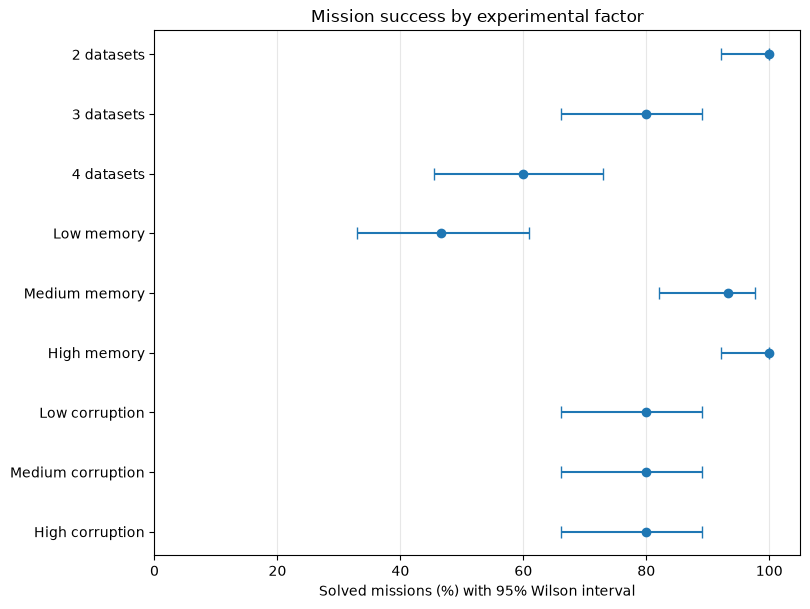

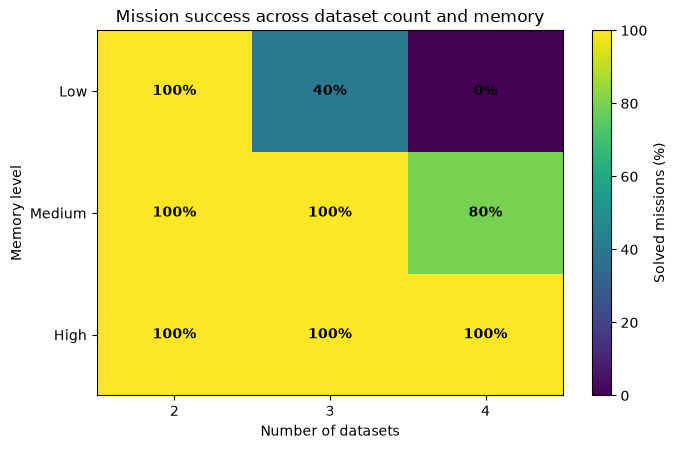

In [6]:
def wilson_interval(
    successes: int,
    total: int,
    z_value: float = 1.959963984540054,
) -> tuple:
    if total <= 0:
        return np.nan, np.nan

    proportion = successes / total
    denominator = 1 + z_value**2 / total
    center = (
        proportion + z_value**2 / (2 * total)
    ) / denominator
    radius = (
        z_value
        * np.sqrt(
            proportion * (1 - proportion) / total
            + z_value**2 / (4 * total**2)
        )
        / denominator
    )

    return max(0.0, center - radius), min(1.0, center + radius)


def success_with_wilson(
    factor: str,
    order,
    factor_label: str,
    label_function,
) -> pd.DataFrame:
    rows = []

    for level in order:
        subset = classified_df[
            classified_df[factor].astype(str).eq(str(level))
        ]
        statuses = subset["classification_status"].astype(str)
        solved = int(statuses.eq("solved").sum())
        total = len(subset)
        lower, upper = wilson_interval(solved, total)

        rows.append(
            {
                "factor": factor_label,
                "level": level,
                "label": label_function(level),
                "solved": solved,
                "total": total,
                "success_percent": 100 * solved / total,
                "ci_low_percent": 100 * lower,
                "ci_high_percent": 100 * upper,
            }
        )

    return pd.DataFrame(rows)


success_rates_wilson = pd.concat(
    [
        success_with_wilson(
            "dataset_count",
            DATASET_ORDER,
            "Dataset count",
            lambda value: f"{value} datasets",
        ),
        success_with_wilson(
            "memory_level",
            MEMORY_ORDER,
            "Memory",
            lambda value: f"{str(value).title()} memory",
        ),
        success_with_wilson(
            "corruption_level",
            CORRUPTION_ORDER,
            "Corruption",
            lambda value: f"{str(value).title()} corruption",
        ),
    ],
    ignore_index=True,
)

display(success_rates_wilson)

plot_df = success_rates_wilson.iloc[::-1].reset_index(drop=True)
positions = np.arange(len(plot_df))
estimates = plot_df["success_percent"].to_numpy()
errors = np.vstack(
    [
        estimates - plot_df["ci_low_percent"].to_numpy(),
        plot_df["ci_high_percent"].to_numpy() - estimates,
    ]
)

fig, ax = plt.subplots(figsize=(8.2, 6.2))
ax.errorbar(
    estimates,
    positions,
    xerr=errors,
    fmt="o",
    capsize=4,
    linewidth=1.5,
)
ax.set_yticks(positions, plot_df["label"])
ax.set_xlim(0, 105)
ax.set_xlabel("Solved missions (%) with 95% Wilson interval")
ax.set_title("Mission success by experimental factor")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "success_rates_wilson_95.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

interaction_matrix = (
    success_dataset_memory.pivot(
        index="memory_level",
        columns="dataset_count",
        values="success_percent",
    )
    .reindex(index=MEMORY_ORDER, columns=DATASET_ORDER)
)

fig, ax = plt.subplots(figsize=(7.0, 4.6))
image = ax.imshow(
    interaction_matrix.to_numpy(),
    vmin=0,
    vmax=100,
    aspect="auto",
)
ax.set_title("Mission success across dataset count and memory")
ax.set_xlabel("Number of datasets")
ax.set_ylabel("Memory level")
ax.set_xticks(range(len(DATASET_ORDER)), DATASET_ORDER)
ax.set_yticks(
    range(len(MEMORY_ORDER)),
    [level.title() for level in MEMORY_ORDER],
)

for row_index in range(interaction_matrix.shape[0]):
    for column_index in range(interaction_matrix.shape[1]):
        value = interaction_matrix.iloc[row_index, column_index]
        ax.text(
            column_index,
            row_index,
            f"{value:.0f}%",
            ha="center",
            va="center",
            fontweight="bold",
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Solved missions (%)")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "success_interaction_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Feasibility result

All two-dataset missions were solved. The success rate fell to 80% with three datasets and 60% with four datasets. Memory was the strongest feasibility factor: low memory solved 46.7% of missions, medium memory solved 93.3%, and high memory solved all missions.

The heatmap shows the interaction clearly. Memory had no visible effect for two-dataset missions, but it became decisive for larger workloads. With four datasets, low memory solved 0% of missions, medium memory solved 80%, and high memory solved 100%.

Corruption severity produced the same overall success rate in the tested ranges, so it did not show a feasibility effect in the final sample.


## 4. Planner runtime

Runtime is analysed using the original 30-second runs only. The later 120-second reruns are excluded so that every runtime value comes from the same computational budget.

The figure compares two values for each mission size:

- the **median**, which represents a typical run;
- the **90th percentile**, which shows the slower end of the distribution without using only the single worst case.


Runtime by dataset count


,dataset_count,instances,mean_runtime,median_runtime,p90_runtime,maximum_runtime,timeouts
0,2,45,0.398100,0.383965,0.448662,0.481760,0
1,3,45,0.797414,0.528247,1.754688,3.438560,0
2,4,45,9.357990,7.314771,25.345049,30.119575,3


Runtime by corruption level


,corruption_level,instances,mean_runtime,median_runtime,p90_runtime,maximum_runtime,timeouts
0,low,45,6.252784,0.532860,25.136196,30.119575,3
1,medium,45,3.286430,0.534489,9.471424,28.444092,0
2,high,45,1.014290,0.458232,2.644699,5.286685,0


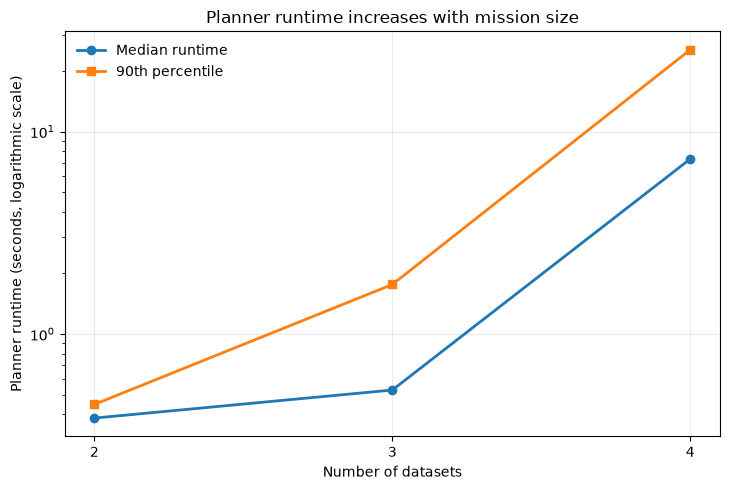

In [7]:
runtime_df = standard_df.copy()
runtime_df["runtime_30s_seconds"] = runtime_df["wall_runtime_seconds"]

runtime_by_dataset = (
    runtime_df.groupby("dataset_count", observed=True)
    .agg(
        instances=("instance_id", "count"),
        mean_runtime=("runtime_30s_seconds", "mean"),
        median_runtime=("runtime_30s_seconds", "median"),
        p90_runtime=(
            "runtime_30s_seconds",
            lambda values: values.quantile(0.90),
        ),
        maximum_runtime=("runtime_30s_seconds", "max"),
        timeouts=("status", lambda values: values.eq("timeout").sum()),
    )
    .reset_index()
)

runtime_by_corruption = (
    runtime_df.groupby("corruption_level", observed=True)
    .agg(
        instances=("instance_id", "count"),
        mean_runtime=("runtime_30s_seconds", "mean"),
        median_runtime=("runtime_30s_seconds", "median"),
        p90_runtime=(
            "runtime_30s_seconds",
            lambda values: values.quantile(0.90),
        ),
        maximum_runtime=("runtime_30s_seconds", "max"),
        timeouts=("status", lambda values: values.eq("timeout").sum()),
    )
    .reset_index()
)

print("Runtime by dataset count")
display(runtime_by_dataset)

print("Runtime by corruption level")
display(runtime_by_corruption)

fig, ax = plt.subplots(figsize=(7.4, 5.0))

ax.plot(
    runtime_by_dataset["dataset_count"],
    runtime_by_dataset["median_runtime"],
    marker="o",
    linewidth=2,
    label="Median runtime",
)

ax.plot(
    runtime_by_dataset["dataset_count"],
    runtime_by_dataset["p90_runtime"],
    marker="s",
    linewidth=2,
    label="90th percentile",
)

ax.set_yscale("log")
ax.set_xticks(DATASET_ORDER)
ax.set_xlabel("Number of datasets")
ax.set_ylabel("Planner runtime (seconds, logarithmic scale)")
ax.set_title("Planner runtime increases with mission size")
ax.grid(alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    PLOT_DIR / "runtime_summary_by_dataset_count.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Runtime result

Two-dataset missions were fast and consistent. Three-dataset missions were still usually fast, but the slower cases began to separate from the median. Four-dataset missions had the largest increase in both typical runtime and slow-case runtime, and they contained all three standard timeouts.

Corruption-level runtime results remain available in the table, but they are not given a separate main figure because the corresponding Kruskal–Wallis test was not significant at the 0.05 level.


## 5. Plan efficiency and battery use

Plan metrics exist only for missions where ENHSP found a plan. They describe the generated satisficing plans and are not claimed to be globally optimal.

Two figures are used here:

- a box-and-point plot showing the battery left after solved missions;
- a scatter plot showing the relationship between movement energy and plan makespan.


Solved-plan metrics by memory


,memory_level,solved_instances,mean_makespan,median_makespan,mean_moves,median_moves,mean_energy_used,median_energy_used,mean_battery_remaining,median_battery_remaining,mean_battery_utilization
0,low,21,25.761905,24.0,7.714286,6.0,24.571429,24.0,15.428571,16.0,0.614286
1,medium,42,28.119048,29.0,8.952381,10.0,30.476190,31.0,9.523810,9.0,0.761905
2,high,45,23.822222,24.0,7.777778,8.0,26.577778,28.0,13.422222,12.0,0.664444


Solved-plan metrics by dataset count


,dataset_count,solved_instances,mean_makespan,median_makespan,mean_moves,median_moves,mean_energy_used,median_energy_used,mean_battery_remaining,median_battery_remaining
0,2,45,19.044444,19.0,5.333333,6.0,18.266667,18.0,21.733333,22.0
1,3,36,30.027778,30.0,9.777778,10.0,31.555556,34.0,8.444444,6.0
2,4,27,31.703704,32.0,10.962963,10.0,38.296296,40.0,1.703704,0.0


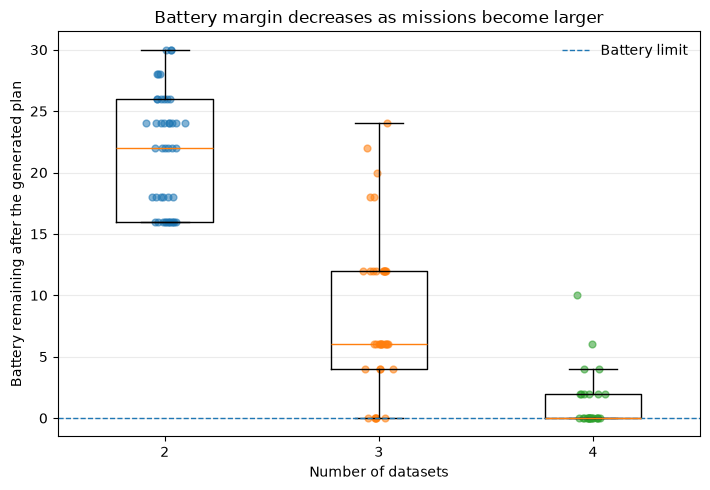

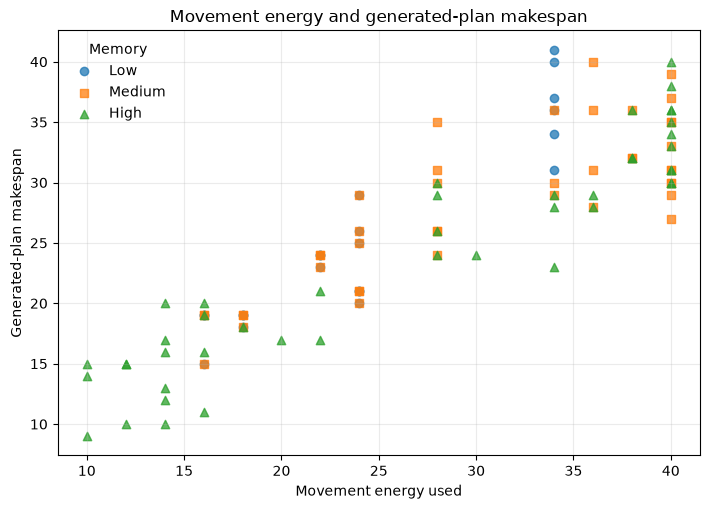

In [8]:
solved_plans = classified_df[
    classified_df["classification_status"].astype(str).eq("solved")
].copy()

plan_metrics_by_memory = (
    solved_plans.groupby("memory_level", observed=True)
    .agg(
        solved_instances=("instance_id", "count"),
        mean_makespan=("plan_makespan", "mean"),
        median_makespan=("plan_makespan", "median"),
        mean_moves=("move_actions", "mean"),
        median_moves=("move_actions", "median"),
        mean_energy_used=("energy_used", "mean"),
        median_energy_used=("energy_used", "median"),
        mean_battery_remaining=("battery_remaining", "mean"),
        median_battery_remaining=("battery_remaining", "median"),
        mean_battery_utilization=(
            "battery_utilization_ratio",
            "mean",
        ),
    )
    .reset_index()
)

plan_metrics_by_dataset = (
    solved_plans.groupby("dataset_count", observed=True)
    .agg(
        solved_instances=("instance_id", "count"),
        mean_makespan=("plan_makespan", "mean"),
        median_makespan=("plan_makespan", "median"),
        mean_moves=("move_actions", "mean"),
        median_moves=("move_actions", "median"),
        mean_energy_used=("energy_used", "mean"),
        median_energy_used=("energy_used", "median"),
        mean_battery_remaining=("battery_remaining", "mean"),
        median_battery_remaining=("battery_remaining", "median"),
    )
    .reset_index()
)

print("Solved-plan metrics by memory")
display(plan_metrics_by_memory)

print("Solved-plan metrics by dataset count")
display(plan_metrics_by_dataset)

standard_solved_plans = standard_df[
    standard_df["status"].astype(str).eq("solved")
    & standard_df["energy_used"].notna()
    & standard_df["battery_remaining"].notna()
    & standard_df["plan_makespan"].notna()
].copy()

# Battery remaining by mission size
battery_groups = [
    standard_solved_plans.loc[
        standard_solved_plans["dataset_count"].eq(dataset_count),
        "battery_remaining",
    ].to_numpy()
    for dataset_count in DATASET_ORDER
]

fig, ax = plt.subplots(figsize=(7.2, 5.0))

ax.boxplot(
    battery_groups,
    positions=DATASET_ORDER,
    widths=0.45,
    showfliers=False,
)

rng = np.random.default_rng(42)

for dataset_count, values in zip(DATASET_ORDER, battery_groups):
    jitter = rng.normal(
        loc=dataset_count,
        scale=0.045,
        size=len(values),
    )
    ax.scatter(
        jitter,
        values,
        alpha=0.55,
        s=24,
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
    label="Battery limit",
)

ax.set_xticks(DATASET_ORDER)
ax.set_xlabel("Number of datasets")
ax.set_ylabel("Battery remaining after the generated plan")
ax.set_title("Battery margin decreases as missions become larger")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    PLOT_DIR / "battery_remaining_by_dataset_count.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Energy and makespan relationship
markers = {
    "low": "o",
    "medium": "s",
    "high": "^",
}

fig, ax = plt.subplots(figsize=(7.2, 5.2))

for memory_level in MEMORY_ORDER:
    subset = standard_solved_plans[
        standard_solved_plans["memory_level"]
        .astype(str)
        .eq(memory_level)
    ]

    ax.scatter(
        subset["energy_used"],
        subset["plan_makespan"],
        label=memory_level.title(),
        marker=markers[memory_level],
        alpha=0.75,
    )

ax.set_title("Movement energy and generated-plan makespan")
ax.set_xlabel("Movement energy used")
ax.set_ylabel("Generated-plan makespan")
ax.grid(alpha=0.25)
ax.legend(title="Memory", frameon=False)

plt.tight_layout()
plt.savefig(
    PLOT_DIR / "energy_vs_makespan_scatter.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Plan-efficiency result

The battery figure shows the remaining energy margin after solved missions. Larger missions generally leave less battery because they require more movement.

The scatter plot shows that plans using more movement energy also tend to have a longer makespan. This is expected because both quantities increase with travel. The plot describes a relationship in the generated plans; it does not prove that energy use alone causes the longer makespan.

All classified solved plans passed the battery and route checks. The unsolvable cases therefore came from the interaction of memory, timing, travel, and energy constraints rather than from a single dataset that was impossible from the start.


## 6. Statistical analysis

The statistical tests are exploratory because the experiment uses synthetic missions and five unseen seeds.

- Chi-square tests compare each experimental factor with final feasibility.
- Kruskal–Wallis tests compare runtime distributions.
- Friedman tests compare memory levels on matched missions where all three memory variants were solved.
- Effect sizes are reported together with the p-values.


In [9]:
def cramers_v(contingency_table: pd.DataFrame) -> tuple:
    """Return chi-square results and Cramér's V."""
    chi2, p_value, degrees_freedom, expected = chi2_contingency(
        contingency_table
    )

    sample_size = contingency_table.to_numpy().sum()
    rows, columns = contingency_table.shape
    denominator = sample_size * min(rows - 1, columns - 1)

    effect_size = (
        np.sqrt(chi2 / denominator)
        if denominator > 0
        else np.nan
    )

    return (
        chi2,
        p_value,
        degrees_freedom,
        expected,
        effect_size,
    )


def epsilon_squared_kruskal(
    statistic: float,
    sample_count: int,
    group_count: int,
) -> float:
    """Exploratory epsilon-squared effect size for Kruskal–Wallis."""
    denominator = sample_count - group_count

    if denominator <= 0:
        return np.nan

    return max(
        0.0,
        (statistic - group_count + 1) / denominator,
    )


statistical_results = []

for factor, order in [
    ("dataset_count", DATASET_ORDER),
    ("memory_level", MEMORY_ORDER),
    ("corruption_level", CORRUPTION_ORDER),
]:
    contingency = pd.crosstab(
        classified_df[factor],
        classified_df["classification_status"],
    ).reindex(
        index=order,
        columns=CLASSIFICATION_STATUS_ORDER,
        fill_value=0,
    )

    print(f"Feasibility contingency table: {factor}")
    display(contingency)

    chi2, p_value, dof, expected, effect_size = cramers_v(
        contingency
    )

    statistical_results.append(
        {
            "analysis": f"Feasibility association: {factor}",
            "test": "Chi-square test of independence",
            "statistic": chi2,
            "p_value": p_value,
            "degrees_of_freedom": dof,
            "effect_size_name": "Cramer's V",
            "effect_size": effect_size,
            "sample_size": int(contingency.to_numpy().sum()),
            "notes": (
                f"Minimum expected count: {expected.min():.3f}"
            ),
        }
    )

for factor, order in [
    ("dataset_count", DATASET_ORDER),
    ("memory_level", MEMORY_ORDER),
    ("corruption_level", CORRUPTION_ORDER),
]:
    samples = [
        runtime_df.loc[
            runtime_df[factor].astype(str).eq(str(level)),
            "runtime_30s_seconds",
        ].dropna()
        for level in order
    ]

    statistic, p_value = kruskal(*samples)
    sample_count = sum(len(sample) for sample in samples)
    effect_size = epsilon_squared_kruskal(
        statistic,
        sample_count,
        len(samples),
    )

    statistical_results.append(
        {
            "analysis": f"Standard runtime difference: {factor}",
            "test": "Kruskal-Wallis",
            "statistic": statistic,
            "p_value": p_value,
            "degrees_of_freedom": len(samples) - 1,
            "effect_size_name": "Epsilon-squared",
            "effect_size": effect_size,
            "sample_size": sample_count,
            "notes": "Includes standard timeout runtimes near 30 seconds.",
        }
    )

statistical_results_df = pd.DataFrame(statistical_results)
display(statistical_results_df)


Feasibility contingency table: dataset_count


classification_status,solved,unsolvable
dataset_count,,
2,45,0
3,36,9
4,27,18


Feasibility contingency table: memory_level


classification_status,solved,unsolvable
memory_level,,
low,21,24
medium,42,3
high,45,0


Feasibility contingency table: corruption_level


classification_status,solved,unsolvable
corruption_level,,
low,36,9
medium,36,9
high,36,9


,analysis,test,statistic,p_value,degrees_of_freedom,effect_size_name,effect_size,sample_size,notes
0,Feasibility association: dataset_count,Chi-square test of independence,22.500000,1.300730e-05,2,Cramer's V,0.408248,135,Minimum expected count: 9.000
1,Feasibility association: memory_level,Chi-square test of independence,47.500000,4.847369e-11,2,Cramer's V,0.593171,135,Minimum expected count: 9.000
2,Feasibility association: corruption_level,Chi-square test of independence,0.000000,1.000000e+00,2,Cramer's V,0.000000,135,Minimum expected count: 9.000
3,Standard runtime difference: dataset_count,Kruskal-Wallis,100.993203,1.173829e-22,2,Epsilon-squared,0.749949,135,Includes standard timeout runtimes near 30 sec...
4,Standard runtime difference: memory_level,Kruskal-Wallis,7.178301,2.762179e-02,2,Epsilon-squared,0.039230,135,Includes standard timeout runtimes near 30 sec...
5,Standard runtime difference: corruption_level,Kruskal-Wallis,4.910414,8.584543e-02,2,Epsilon-squared,0.022049,135,Includes standard timeout runtimes near 30 sec...


In [10]:
def run_matched_memory_test(metric: str) -> dict:
    """Compare memory levels on complete matched solved-mission blocks."""
    pivot = (
        solved_plans.pivot_table(
            index=[
                "dataset_count",
                "corruption_level",
                "seed",
            ],
            columns="memory_level",
            values=metric,
            aggfunc="first",
            observed=True,
        )
        .reindex(columns=MEMORY_ORDER)
        .dropna()
    )

    if len(pivot) < 2:
        return {
            "analysis": f"Matched memory comparison: {metric}",
            "test": "Friedman",
            "statistic": np.nan,
            "p_value": np.nan,
            "degrees_of_freedom": 2,
            "effect_size_name": "Kendall's W",
            "effect_size": np.nan,
            "sample_size": len(pivot),
            "notes": "Insufficient complete matched blocks.",
        }

    statistic, p_value = friedmanchisquare(
        pivot["low"],
        pivot["medium"],
        pivot["high"],
    )

    kendalls_w = statistic / (
        len(pivot) * (len(MEMORY_ORDER) - 1)
    )

    return {
        "analysis": f"Matched memory comparison: {metric}",
        "test": "Friedman",
        "statistic": statistic,
        "p_value": p_value,
        "degrees_of_freedom": 2,
        "effect_size_name": "Kendall's W",
        "effect_size": kendalls_w,
        "sample_size": len(pivot),
        "notes": (
            "Complete matched blocks where low, medium, and high "
            "memory variants were all solved."
        ),
    }


matched_tests = pd.DataFrame(
    [
        run_matched_memory_test("move_actions"),
        run_matched_memory_test("energy_used"),
        run_matched_memory_test("plan_makespan"),
    ]
)

statistical_results_df = pd.concat(
    [statistical_results_df, matched_tests],
    ignore_index=True,
)

display(matched_tests)


,analysis,test,statistic,p_value,degrees_of_freedom,effect_size_name,effect_size,sample_size,notes
0,Matched memory comparison: move_actions,Friedman,35.292308,2.169565e-08,2,Kendall's W,0.840293,21,"Complete matched blocks where low, medium, and..."
1,Matched memory comparison: energy_used,Friedman,35.292308,2.169565e-08,2,Kendall's W,0.840293,21,"Complete matched blocks where low, medium, and..."
2,Matched memory comparison: plan_makespan,Friedman,34.238806,3.673988e-08,2,Kendall's W,0.815210,21,"Complete matched blocks where low, medium, and..."


In [11]:
feasibility_effect_sizes = (
    statistical_results_df[
        statistical_results_df["analysis"]
        .str.startswith("Feasibility association:")
    ][
        [
            "analysis",
            "statistic",
            "p_value",
            "effect_size_name",
            "effect_size",
            "sample_size",
        ]
    ]
    .copy()
)

factor_names = {
    "dataset_count": "Dataset count",
    "memory_level": "Memory level",
    "corruption_level": "Corruption level",
}

feasibility_effect_sizes["factor"] = (
    feasibility_effect_sizes["analysis"]
    .str.split(": ", n=1)
    .str[-1]
    .map(factor_names)
)

feasibility_effect_sizes = feasibility_effect_sizes[
    [
        "factor",
        "statistic",
        "p_value",
        "effect_size_name",
        "effect_size",
        "sample_size",
    ]
].sort_values(
    "effect_size",
    ascending=False,
)

display(feasibility_effect_sizes)


,factor,statistic,p_value,effect_size_name,effect_size,sample_size
1,Memory level,47.5,4.847369e-11,Cramer's V,0.593171,135
0,Dataset count,22.5,1.300730e-05,Cramer's V,0.408248,135
2,Corruption level,0.0,1.000000e+00,Cramer's V,0.000000,135


### Statistical result

Memory level had the strongest observed association with mission feasibility, followed by dataset count. Corruption level showed no association with final feasibility in the tested ranges.

Dataset count had a strong effect on standard planner runtime. The matched-memory tests also showed that memory level changed movement count, energy use, and makespan among missions solved under all three memory settings.

The statistical values are kept in tables rather than repeated in another graph. This keeps the visual analysis focused on the five main research questions.


## 7. Export the analysis results

The notebook saves the result tables and the five main figures used to explain the study.


In [12]:
exports = {
    "status_standard_vs_classified.csv": (
        status_table.reset_index().rename(
            columns={"index": "status"}
        )
    ),
    "extended_classifications.csv": extended_cases,
    "success_by_dataset_count.csv": success_by_dataset,
    "success_by_memory.csv": success_by_memory,
    "success_by_corruption.csv": success_by_corruption,
    "success_dataset_memory_interaction.csv": (
        success_dataset_memory
    ),
    "success_rates_wilson_95.csv": success_rates_wilson,
    "runtime_by_dataset_count.csv": runtime_by_dataset,
    "runtime_by_corruption.csv": runtime_by_corruption,
    "solved_plan_metrics_by_memory.csv": (
        plan_metrics_by_memory
    ),
    "solved_plan_metrics_by_dataset_count.csv": (
        plan_metrics_by_dataset
    ),
    "statistical_tests.csv": statistical_results_df,
    "feasibility_effect_sizes.csv": feasibility_effect_sizes,
}

for filename, table in exports.items():
    table.to_csv(
        TABLE_DIR / filename,
        index=False,
    )

expected_plots = [
    "success_rates_wilson_95.png",
    "success_interaction_heatmap.png",
    "runtime_summary_by_dataset_count.png",
    "battery_remaining_by_dataset_count.png",
    "energy_vs_makespan_scatter.png",
]

missing_plots = [
    filename
    for filename in expected_plots
    if not (PLOT_DIR / filename).exists()
]

assert not missing_plots, f"Missing plots: {missing_plots}"

print(f"Saved {len(exports)} analysis tables.")
print(f"Saved {len(expected_plots)} main figures.")


Saved 13 analysis tables.
Saved 5 main figures.


## 8. Conclusions

The final experiment gives four main results:

1. **Mission size matters.** Increasing the workload from two to four datasets reduced feasibility, increased runtime, and reduced the remaining battery margin.
2. **Memory is the main feasibility bottleneck.** Its effect became stronger as the number of datasets increased.
3. **Travel connects energy and time.** Plans with greater movement-energy use generally had a longer makespan.
4. **Corruption did not affect feasibility in the tested ranges.** Its runtime difference was also not statistically significant at the 0.05 level.

The study shows why the constraints should be considered together. A memory setting that is sufficient for a small mission may fail completely when the workload grows, even when each dataset is individually safe and the battery capacity stays fixed.


## 9. ROS 2 demonstration

The notebook now sends one request to the same ROS 2 service used by the project. The returned battery values are checked and saved as a reproducibility table.

Start the ROS 2 experiment service in a separate terminal before running the next cell.


In [13]:
import json
import subprocess

ros_command = f"""
source /opt/ros/jazzy/setup.bash
source "{PROJECT_ROOT}/ros2_ws/install/setup.bash"
cd "{PROJECT_ROOT}"

ros2 run rover_experiment_ros experiment_client \
  --datasets 3 \
  --memory medium \
  --corruption medium \
  --seed 0 \
  --timeout 30
"""

completed = subprocess.run(
    ["bash", "-lc", ros_command],
    capture_output=True,
    text=True,
    timeout=45,
    check=False,
)

if completed.returncode != 0:
    raise RuntimeError(
        "ROS 2 experiment client failed.\n\n"
        f"Standard output:\n{completed.stdout}\n\n"
        f"Standard error:\n{completed.stderr}"
    )

output_text = completed.stdout.strip()

json_start = output_text.find("{")
json_end = output_text.rfind("}")

if json_start < 0 or json_end < json_start:
    raise RuntimeError(
        "Could not find the JSON result in the ROS client output:\n"
        + output_text
    )

ros_result = json.loads(
    output_text[json_start:json_end + 1]
)

ros_result_table = pd.DataFrame([ros_result])

display(
    ros_result_table[
        [
            "instance_id",
            "status",
            "wall_runtime_seconds",
            "plan_makespan",
            "action_count",
            "move_actions",
            "battery_capacity",
            "energy_used",
            "battery_remaining",
            "battery_feasible",
        ]
    ]
)

assert ros_result["instance_id"] == (
    "rover-battery-n3-mem-medium-corr-medium-seed-0"
)
assert ros_result["status"] == "solved"
assert ros_result["solved"] is True
assert ros_result["battery_feasible"] is True
assert ros_result["battery_capacity"] > 0
assert ros_result["energy_used"] >= 0
assert ros_result["battery_remaining"] >= 0

calculated_remaining = (
    ros_result["battery_capacity"]
    - ros_result["energy_used"]
)

assert abs(
    calculated_remaining
    - ros_result["battery_remaining"]
) < 1e-9

ros_result_table.to_csv(
    TABLE_DIR / "ros_battery_demonstration.csv",
    index=False,
)

print("ROS 2 battery notebook integration passed.")


,instance_id,status,wall_runtime_seconds,plan_makespan,action_count,move_actions,battery_capacity,energy_used,battery_remaining,battery_feasible
0,rover-battery-n3-mem-medium-corr-medium-seed-0,solved,0.645272,28.0,16,10,40.0,26.0,14.0,True


ROS 2 battery notebook integration passed.


## 10. Reproducibility information

- Original runtime results: `experiments/results/battery_final_unseen.csv`
- Final classifications: `experiments/results/battery_final_unseen_classified.csv`
- Final seeds: 10–14
- Development seeds: 0–4
- Standard timeout: 30 seconds
- Classification timeout: 120 seconds
- Planner: ENHSP `sat-hadd`
- Battery capacity: 40 energy units
- Final experiment size: 135 missions

The statistical results use only the final unseen seeds. The longer reruns are used only for final feasibility classification and are not mixed into the runtime comparison.
